In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/raw/House_Prices.csv")

print(df.shape)
print(df.info())
df = df.drop(columns=['Id'])
print(df)

(2919, 81)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             2919 non-null   int64  
 1   MSSubClass     2919 non-null   int64  
 2   MSZoning       2915 non-null   object 
 3   LotFrontage    2433 non-null   float64
 4   LotArea        2919 non-null   int64  
 5   Street         2919 non-null   object 
 6   Alley          198 non-null    object 
 7   LotShape       2919 non-null   object 
 8   LandContour    2919 non-null   object 
 9   Utilities      2917 non-null   object 
 10  LotConfig      2919 non-null   object 
 11  LandSlope      2919 non-null   object 
 12  Neighborhood   2919 non-null   object 
 13  Condition1     2919 non-null   object 
 14  Condition2     2919 non-null   object 
 15  BldgType       2919 non-null   object 
 16  HouseStyle     2919 non-null   object 
 17  OverallQual    2919 non-null   int64  
 1

0


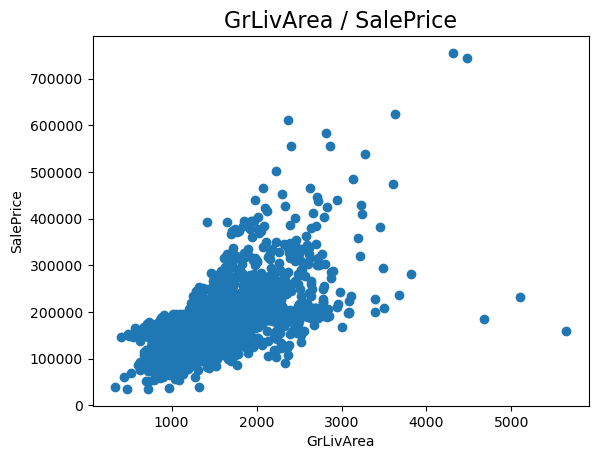

In [24]:
df["MSSubClass"] = df["MSSubClass"].astype(str)
df["MoSold"] = df["MoSold"].astype(str)
df["YrSold"] = df["YrSold"].astype(str)

missing = df.isnull().sum()
missing = missing[missing > 0]

cols_to_none = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 
                'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 
                'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 
                'BsmtFinType2', 'MasVnrType']

cols_to_zero = ['GarageYrBlt', 'GarageArea', 'GarageCars', 'BsmtFinSF1', 
                'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 
                'BsmtHalfBath', 'MasVnrArea']


for col in missing.index:
    if col in cols_to_none:
        df[col] = df[col].fillna("None")
    elif col in cols_to_zero:
        df[col] = df[col].fillna(0)
    elif col == "LotFrontage":
        df[col] = df[col].fillna(df.groupby("Neighborhood")[col].transform("median"))
    else :
        df[col] = df[col].fillna(df[col].mode()[0])

print(df.isnull().sum().sum())


plt.scatter(df['GrLivArea'], df['SalePrice'])

plt.title("GrLivArea / SalePrice",fontsize=16)
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")

plt.show()


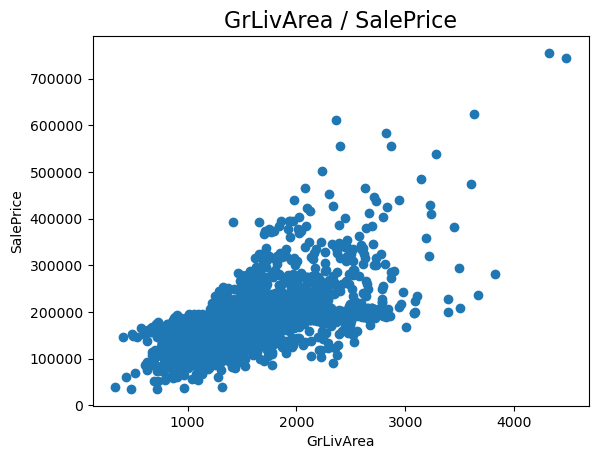

In [25]:

out_values = (df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)
df = df[~out_values]




plt.scatter(df['GrLivArea'], df['SalePrice'])

plt.title("GrLivArea / SalePrice",fontsize=16)
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")

plt.show()


In [29]:

y = df['SalePrice']
x = df.drop(columns='SalePrice')

print(x)
print(y)

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

df.to_csv("../data/processed/cleaned_house_prices.csv")

     MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0            60       RL         65.0     8450   Pave  None      Reg   
1            20       RL         80.0     9600   Pave  None      Reg   
2            60       RL         68.0    11250   Pave  None      IR1   
3            70       RL         60.0     9550   Pave  None      IR1   
4            60       RL         84.0    14260   Pave  None      IR1   
...         ...      ...          ...      ...    ...   ...      ...   
2914        160       RM         21.0     1936   Pave  None      Reg   
2915        160       RM         21.0     1894   Pave  None      Reg   
2916         20       RL        160.0    20000   Pave  None      Reg   
2917         85       RL         62.0    10441   Pave  None      Reg   
2918         60       RL         74.0     9627   Pave  None      Reg   

     LandContour Utilities LotConfig  ... ScreenPorch PoolArea PoolQC  Fence  \
0            Lvl    AllPub    Inside  ...           0  

In [34]:
# df['SalePrice'] = round(df['SalePrice'], 0)
print(df['SalePrice'].to_string())

0       208500.0
1       181500.0
2       223500.0
3       140000.0
4       250000.0
5       143000.0
6       307000.0
7       200000.0
8       129900.0
9       118000.0
10      129500.0
11      345000.0
12      144000.0
13      279500.0
14      157000.0
15      132000.0
16      149000.0
17       90000.0
18      159000.0
19      139000.0
20      325300.0
21      139400.0
22      230000.0
23      129900.0
24      154000.0
25      256300.0
26      134800.0
27      306000.0
28      207500.0
29       68500.0
30       40000.0
31      149350.0
32      179900.0
33      165500.0
34      277500.0
35      309000.0
36      145000.0
37      153000.0
38      109000.0
39       82000.0
40      160000.0
41      170000.0
42      144000.0
43      130250.0
44      141000.0
45      319900.0
46      239686.0
47      249700.0
48      113000.0
49      127000.0
50      177000.0
51      114500.0
52      110000.0
53      385000.0
54      130000.0
55      180500.0
56      172500.0
57      196500.0
58      438780